## 1. Food Delivery Locations and Initial Centroids

Point [2, 3] -> Cluster 1 | distances = [0.0, 7.211]
Point [5, 8] -> Cluster 2 | distances = [5.831, 1.414]
Point [1, 2] -> Cluster 1 | distances = [1.414, 8.602]
Point [6, 9] -> Cluster 2 | distances = [7.211, 0.0]
Point [7, 7] -> Cluster 2 | distances = [6.403, 2.236]
Assignments: [1, 2, 1, 2, 2]


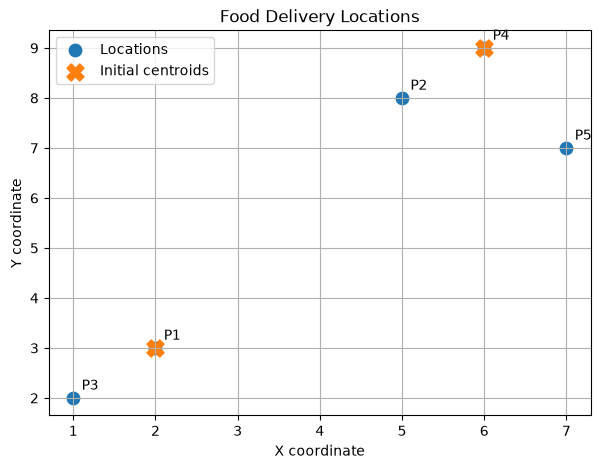

In [6]:
import math
import matplotlib.pyplot as plt

points = [[2, 3], [5, 8], [1, 2], [6, 9], [7, 7]]
centroids = [[2, 3], [6, 9]]

def euclidean(a, b):
    return math.sqrt(sum((x-y)**2 for x,y in zip(a,b)))

assignments = []
for point in points:
    distances = [euclidean(point, centroid) for centroid in centroids]
    cluster = distances.index(min(distances)) + 1
    assignments.append(cluster)
    print(f'Point {point} -> Cluster {cluster} | distances = {[round(d, 3) for d in distances]}')

print('Assignments:', assignments)

plt.figure(figsize=(7,5))
plt.scatter([p[0] for p in points], [p[1] for p in points], s=80, label='Locations')
plt.scatter([c[0] for c in centroids], [c[1] for c in centroids], s=150, marker='X', label='Initial centroids')
for i,p in enumerate(points):
    plt.annotate(f'P{i+1}', p, xytext=(6,6), textcoords='offset points')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Food Delivery Locations')
plt.grid(True)
plt.legend()
plt.show()

## 2. Euclidean Distance Cluster Assignment

In [7]:
def assign_clusters(points, centroids):
    assignments = []
    for point in points:
        distances = [math.sqrt(sum((x-y)**2 for x,y in zip(point, centroid))) for centroid in centroids]
        assignments.append(distances.index(min(distances)) + 1)
    return assignments

assign_clusters(points, centroids)

[1, 2, 1, 2, 2]

## 3. Euclidean and Manhattan Distance

In [8]:
def assign_clusters(points, centroids, metric='euclidean'):
    assignments = []
    for point in points:
        if metric == 'euclidean':
            distances = [math.sqrt(sum((x-y)**2 for x,y in zip(point, centroid))) for centroid in centroids]
        elif metric == 'manhattan':
            distances = [sum(abs(x-y) for x,y in zip(point, centroid)) for centroid in centroids]
        else:
            raise ValueError("metric must be 'euclidean' or 'manhattan'")
        assignments.append(distances.index(min(distances)) + 1)
    return assignments

print('Euclidean:', assign_clusters(points, centroids, 'euclidean'))
print('Manhattan:', assign_clusters(points, centroids, 'manhattan'))

Euclidean: [1, 2, 1, 2, 2]
Manhattan: [1, 2, 1, 2, 2]


## 4. Updating Centroids

In [9]:
def update_centroids(points, assignments, k):
    centroids = []
    for cluster_id in range(1, k+1):
        cluster_points = [p for p,a in zip(points, assignments) if a == cluster_id]
        centroids.append([sum(values)/len(values) for values in zip(*cluster_points)] if cluster_points else None)
    return centroids

sample_points = [[1, 2], [2, 3], [8, 9], [9, 10], [4, 5], [5, 4]]
sample_assignments = [1, 1, 2, 2, 1, 1]
print('Points:', sample_points)
print('Assignments:', sample_assignments)
print('Updated centroids:', update_centroids(sample_points, sample_assignments, 2))

Points: [[1, 2], [2, 3], [8, 9], [9, 10], [4, 5], [5, 4]]
Assignments: [1, 1, 2, 2, 1, 1]
Updated centroids: [[3.0, 3.5], [8.5, 9.5]]


## 5. Elbow Method

k: [1, 2, 3, 4, 5, 6]
Within-cluster sum of squares: [4213.029, 1062.976, 467.2, 256.447, 162.508, 108.703]
Elbow point: k = 3


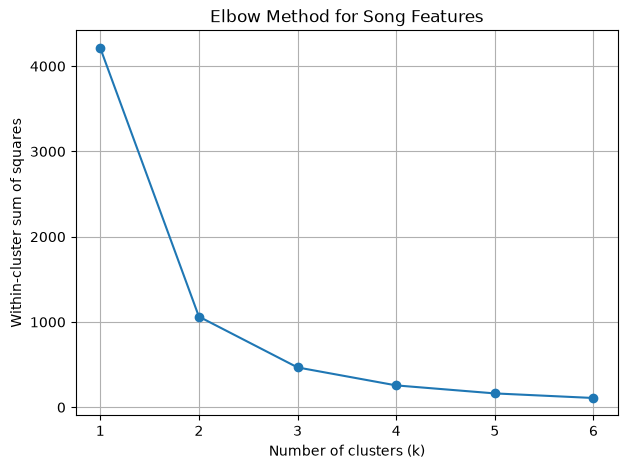

In [10]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

songs = np.array([[55, 0.82], [60, 0.75], [70, 0.78], [80, 0.85], [90, 0.72], [50, 0.65], [65, 0.68], [75, 0.8], [85, 0.76], [95, 0.7], [58, 0.79], [68, 0.73], [78, 0.83], [88, 0.74], [98, 0.67], [52, 0.61], [63, 0.71], [73, 0.77], [83, 0.81], [93, 0.69]])
k_values = range(1, 7)
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(songs)
    inertias.append(model.inertia_)

print('k:', list(k_values))
print('Within-cluster sum of squares:', [round(x,3) for x in inertias])
print('Elbow point: k = 3')

plt.figure(figsize=(7,5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares')
plt.title('Elbow Method for Song Features')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()